In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler, Normalizer,
    LabelEncoder, OneHotEncoder, OrdinalEncoder
)

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("adult.csv")

# Make a copy 
df_clean = df.copy()

In [ ]:
# print general info about the info
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB
None


In [39]:
print("\n--- القيم المفقودة ---")
# this will replace the ? to be reconaized as messing data
df = df.replace("?", np.nan)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Count'] > 0])
print(f"عدد الصفوف المكررة: {df.duplicated().sum()}")


--- القيم المفقودة ---
                Count  Percentage
workclass        1836        5.64
occupation       1843        5.66
native.country    582        1.79
عدد الصفوف المكررة: 0


In [12]:
# remove duplicate rows
df = df.drop_duplicates()
print(f"عدد الصفوف المكررة: {df.duplicated().sum()}")

عدد الصفوف المكررة: 0


In [ ]:
# here you just change the column to the column target
t="target"
X = df.drop(t, axis=1)
y = df[t]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# handling the missing data
categorical_cols = ['workclass', 'occupation', 'native.country']

imputer = SimpleImputer(strategy="most_frequent")
# apply to the training set
X_train[categorical_cols] = imputer.fit_transform(
    X_train[categorical_cols]
)

# apply same learned values to testing set
X_test[categorical_cols] = imputer.transform(
    X_test[categorical_cols]
)

In [ ]:
#the database has no missing values
print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


In [ ]:
def detect_outliers_iqr(df, column):
    """كشف القيم الشاذة باستخدام طريقة IQR"""
    # Q1 = X_train[column].quantile(0.25)
    # Q3 = X_train[column].quantile(0.75)
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return outliers, lower, upper
# search for outliers in the column(age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week)
outliers_iqr1, lower1, upper1 = detect_outliers_iqr(X_train, 'age')
print(f"Outliers في age (IQR): {len(outliers_iqr1)} قيمة")
print(f"  الحد الأدنى المقبول: {lower1:.0f}  |  الحد الأعلى: {upper1:.0f}")
#----------------------------
outliers_iqr2, lower2, upper2 = detect_outliers_iqr(X_train, 'fnlwgt')
print(f"Outliers في fnlwgt (IQR): {len(outliers_iqr2)} قيمة")
print(f"  الحد الأدنى المقبول: {lower2:.0f}  |  الحد الأعلى: {upper2:.0f}")

#-----------------------------
outliers_iqr3, lower3, upper3 = detect_outliers_iqr(X_train, 'capital.gain')
print(f"Outliers في capital.gain (IQR): {len(outliers_iqr3)} قيمة")
print(f"  الحد الأدنى المقبول: {lower3:.0f}  |  الحد الأعلى: {upper3:.0f}")
#-----------------------------
outliers_iqr4, lower4, upper4 = detect_outliers_iqr(X_train, 'capital.loss')
print(f"Outliers في capital.loss (IQR): {len(outliers_iqr4)} قيمة")
print(f"  الحد الأدنى المقبول: {lower4:.0f}  |  الحد الأعلى: {upper4:.0f}")
#-----------------------------
outliers_iqr5, lower5, upper5 = detect_outliers_iqr(X_train, 'hours.per.week')
print(f"Outliers في hours.per.week (IQR): {len(outliers_iqr5)} قيمة")
print(f"  الحد الأدنى المقبول: {lower5:.0f}  |  الحد الأعلى: {upper5:.0f}")



Outliers في age (IQR): 143 قيمة
  الحد الأدنى المقبول: -2  |  الحد الأعلى: 78
Outliers في fnlwgt (IQR): 992 قيمة
  الحد الأدنى المقبول: -61009  |  الحد الأعلى: 415887
Outliers في capital.gain (IQR): 2712 قيمة
  الحد الأدنى المقبول: 0  |  الحد الأعلى: 0
Outliers في capital.loss (IQR): 1519 قيمة
  الحد الأدنى المقبول: 0  |  الحد الأعلى: 0
Outliers في hours.per.week (IQR): 9008 قيمة
  الحد الأدنى المقبول: 32  |  الحد الأعلى: 52


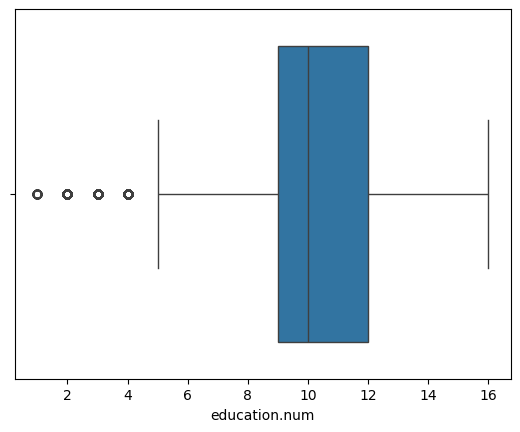

In [ ]:

# to show the data destripution
# needs irq cause of the distribution
    # sns.boxplot(x=df["fnlwgt"])
    # plt.show()
# needs irq cause of the distribution
    # sns.boxplot(x=df["hours.per.week"])
    # plt.show()
#  does not need irq cause of the distribution
    # sns.boxplot(x=df["age"])
    # plt.show()
# sns.boxplot(x=df["capital.loss"])
# plt.show()
# sns.boxplot(x=df["capital.gain"])
# plt.show()
#  does not need irq cause of the distribution
    # sns.boxplot(x=df["education.num"])
    # plt.show()

In [ ]:
# to fix the outliers in each one of the column
# X_train['age'] = X_train['age'].clip(lower=lower1, upper=upper1)
# X_test['age'] = X_test['age'].clip(lower=lower1, upper=upper1)
# #--------------------
X_train['fnlwgt'] = X_train['fnlwgt'].clip(lower=lower2, upper=upper2)
X_test['fnlwgt'] = X_test['fnlwgt'].clip(lower=lower2, upper=upper2)
#--------------------
X_train['capital.gain'] = X_train['capital.gain'].clip(lower=lower3, upper=upper3)
X_test['capital.gain'] = X_test['capital.gain'].clip(lower=lower3, upper=upper3)
#--------------------
X_train['capital.loss'] = X_train['capital.loss'].clip(lower=lower4, upper=upper4)
X_test['capital.loss'] = X_test['capital.loss'].clip(lower=lower4, upper=upper4)
#--------------------
X_train['hours.per.week'] = X_train['hours.per.week'].clip(lower=lower5, upper=upper5)
X_test['hours.per.week'] = X_test['hours.per.week'].clip(lower=lower5, upper=upper5)

In [ ]:


s = StandardScaler()

numeric_cols = ['age', 'fnlwgt', 'capital.gain', 'capital.loss', 'hours.per.week']

X_train[numeric_cols] = s.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = s.transform(X_test[numeric_cols])

In [ ]:
# to encode the strings valued columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

X_train = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=True
)

X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

In [ ]:
# to encode the target columns value too
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)